## Описание задачи

Поступила задача от обсерватории придумать, как с помощью нейросети определять температуру на поверхности обнаруженных звёзд. Обсерватория-заказчик хочет внедрить технологии машинного обучения для предсказания температуры звёзд, в надежде что этот метод будет наиболее точным и удобным, чем принятые в данной сфере методы. В базе обсерватории есть характеристики уже изученных 240 звёзд с шестью признаками по каждой звезде, а именно:

    - Относительная светимость L/Lo — светимость звезды относительно Солнца.
    - Относительный радиус R/Ro — радиус звезды относительно радиуса Солнца.
    - Абсолютная звёздная величина Mv — физическая величина, характеризующая блеск звезды.
    - Звёздный цвет — цвет звезды, который определяют на основе спектрального анализа.
    - Тип звезды. (Номер, соответствующий типу: Коричневый карлик - 0, Красный карлик	- 1, Белый карлик - 2, Звёзды главной последовательности - 3, Сверхгигант - 4, Гипергигант	- 5)
    - Абсолютная температура T(K) — температура на поверхности звезды в Кельвинах.
    
В результате исследования планируется разработать нейронную сеть, которая поможет предсказывать абсолютную температуру на поверхности звезды.

## Загрузка данных

In [1]:
!pip install scikit-learn==1.1.3 matplotlib==3.5.2 phik shap -q

import pandas as pd
import re
from phik import phik_matrix
import numpy as np
import copy 
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
import torch.optim as optim
import random
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt


In [2]:
class_6 = pd.read_csv('/datasets/6_class.csv')

In [3]:
class_6

,Unnamed: 0,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color
0,0,3068,0.002400,0.1700,16.12,0,Red
1,1,3042,0.000500,0.1542,16.60,0,Red
2,2,2600,0.000300,0.1020,18.70,0,Red
3,3,2800,0.000200,0.1600,16.65,0,Red
4,4,1939,0.000138,0.1030,20.06,0,Red
...,...,...,...,...,...,...,...
235,235,38940,374830.000000,1356.0000,-9.93,5,Blue
236,236,30839,834042.000000,1194.0000,-10.63,5,Blue
237,237,8829,537493.000000,1423.0000,-10.73,5,White
238,238,9235,404940.000000,1112.0000,-11.23,5,White


Видим в загруженном файле 240 объектов и 6 признаков. Кроме того, один признак дублирует индексы, можем его сразу удалить.

In [4]:
 class_6.drop('Unnamed: 0', axis=1, inplace=True)

In [5]:
class_6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
dtypes: float64(3), int64(2), object(1)
memory usage: 11.4+ KB


Видим, что типы данных столбцов соответствуют их содержанию

## Предобработка и анализ данных

Приведем данные к snake_case

In [6]:
def to_snake_case(name):
    intermediate = name.replace(' ', '_').replace('(', '_').replace(')', '_').replace('/', '_').lower()
    
   
    result = re.sub(r'([A-Z0-9]+)(?=[a-z0-9])', r'_\1', intermediate)
    
     
    result = re.sub(r'__+', '_', result)
    
     
    result = result.strip('_')
    
    return result

# Создаем словарь с переименованиями колонок
rename_dict = {col: to_snake_case(col) for col in class_6.columns}
# Переименовываем колонки в датафрейме
class_6.rename(columns=rename_dict, inplace=True)

Проверим данные на пропуски

In [7]:
class_6.isnull().sum()

temperature_k            0
luminosity_l_lo          0
radius_r_ro              0
absolute_magnitude_mv    0
star_type                0
star_color               0
dtype: int64

Пропуски отсутствуют

Теперь проверим данные на полные дубликаты

In [8]:
class_6.duplicated().sum()

0

Теперь посмотрим на уникальные значения категориальных столбцов, чтобы устранить некорректные значения (при наличии)

In [9]:
class_6['star_color'].unique()

array(['Red', 'Blue White', 'White', 'Yellowish White', 'Blue white',
       'Pale yellow orange', 'Blue', 'Blue-white', 'Whitish',
       'yellow-white', 'Orange', 'White-Yellow', 'white', 'Blue ',
       'yellowish', 'Yellowish', 'Orange-Red', 'Blue white ',
       'Blue-White'], dtype=object)

In [10]:
class_6['star_color'] = class_6['star_color'].replace({
    'White yellow': 'Yellowish white',
    'Blue White': 'Blue white',
    'Blue-white': 'Blue white',
    'Blue white ': 'Blue white',
    'Blue-White': 'Blue white',
    'white': 'White',
    'Whitish': 'White',
    'Yellowish White': 'Yellowish white',
    'yellow-white': 'Yellowish white',
    'White-Yellow': 'Yellowish white',
    'Blue ': 'Blue',
    'yellowish': 'Yellow',
    'Yellowish': 'Yellow',
    'Orange-Red': 'Orange', 
    'Pale yellow orange': 'Orange'
    
    
})

In [11]:
class_6['star_color'].unique()

array(['Red', 'Blue white', 'White', 'Yellowish white', 'Orange', 'Blue',
       'Yellow'], dtype=object)

В итоге осталось только 7 цветов в соответствии с Гарвардской классификации.

Теперь в посмотрим на категории в следующем признаке

In [12]:
class_6['star_type'].unique()

array([0, 1, 2, 3, 4, 5])

Здесь категории в порядке

Теперь посмотрим на статистические данные датасета

In [13]:
class_6.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_k,240.0,10497.462500,9552.425037,1939.00000,3344.250000,5776.0000,15055.5000,40000.00
luminosity_l_lo,240.0,107188.361635,179432.244940,0.00008,0.000865,0.0705,198050.0000,849420.00
radius_r_ro,240.0,237.157781,517.155763,0.00840,0.102750,0.7625,42.7500,1948.50
absolute_magnitude_mv,240.0,4.382396,10.532512,-11.92000,-6.232500,8.3130,13.6975,20.06
star_type,240.0,2.500000,1.711394,0.00000,1.000000,2.5000,4.0000,5.00


Видим, что наши количественные признаки имеют очень большой разброс значений: стандартное отклонение сопоставимо или даже превышает среднее.
При этом для большинства признаков (кроме абсолютной звездной величины) медиана значительно ниже среднего, что свидетельствует о наличии выбросов или асимметричном распределении.
В выборке присутствуют как очень маленькие/тусклые/холодные объекты, так и экстремально большие/яркие/горячие звёзды.
ТАк как данные отличаются на несколько порядков потребуется стандартизация.

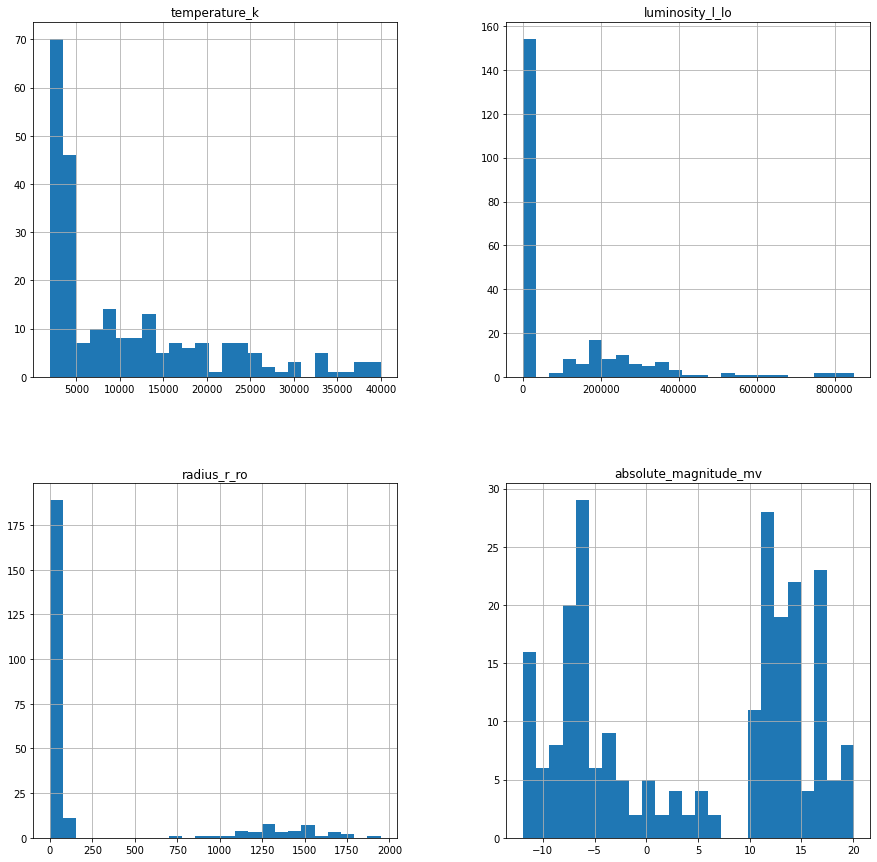

In [14]:
class_6[['temperature_k', 'luminosity_l_lo', 'radius_r_ro', 'absolute_magnitude_mv']].hist(figsize=(15, 15), bins = 25);

Видим, что все четыре наших количественных признака не распределены нормально.

Сначала посмотрим на распределение дискретных признаков, а потом на распределение нерперывных в зависимости от значений дискретных

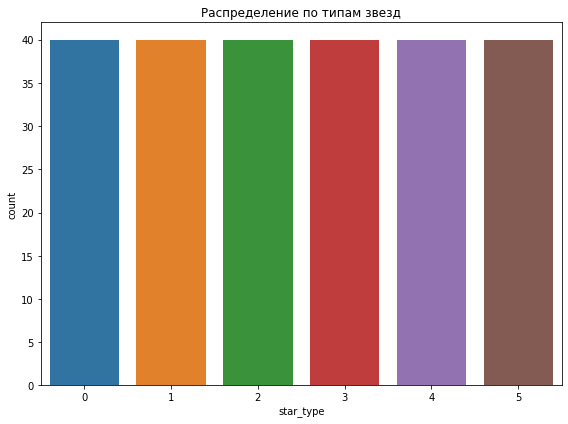

In [15]:

plt.figure(figsize=(8, 6))
sns.countplot(x='star_type', data=class_6)
plt.title('Распределение по типам звезд')
plt.tight_layout()
plt.show()

Видим, что количество звезд каждого типа одинаково - по 40 единиц.

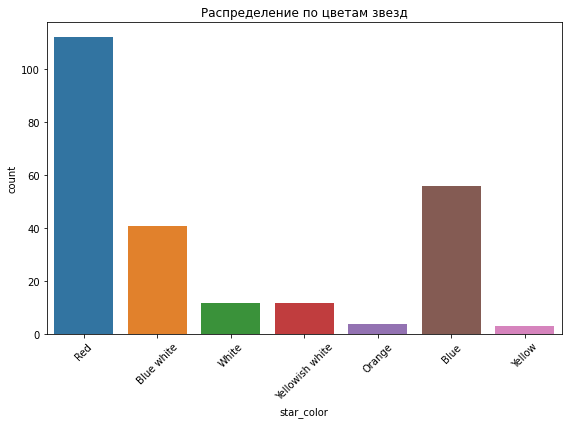

In [16]:

plt.figure(figsize=(8, 6))
sns.countplot(x='star_color', data=class_6)
plt.xticks(rotation=45)
plt.title('Распределение по цветам звезд')
plt.tight_layout()
plt.show()


Видим, что больше всего красных звезд - около 110 единиц, голубых звезд около 60 единиц и бело-голубых - около 40 единиц. На остальные звезды приходится около 15% всей выборки.

Теперь посмотрим на непрерывные признаки

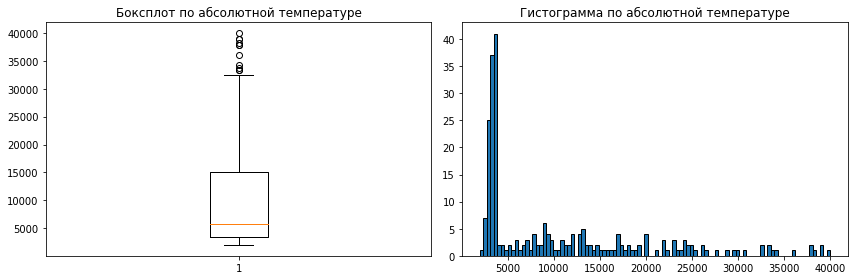

count      240.000000
mean     10497.462500
std       9552.425037
min       1939.000000
25%       3344.250000
50%       5776.000000
75%      15055.500000
max      40000.000000
Name: temperature_k, dtype: float64

In [17]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(class_6['temperature_k'])
axes[0].set_title('Боксплот по абсолютной температуре')

# Второй график — гистограмма
axes[1].hist(class_6['temperature_k'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по абсолютной температуре')


# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
class_6['temperature_k'].describe()

Видим, что распределение с очень сильным скосом вправо. Медиана значитеьно ниже среднего, которое вверх тянут редкие очень сильные выбросы. Видим выбросы выше уровня около 3400 градусов. Однако как будет видно на следующей диаграмме в случае, когда мы рассматриваем температуру в зависимости от типа звезды, данные уже не являются выбросами. В любом случае на данном этапе предлагается аномальные значения оставить, так как это конкретные реалистичные данные, и выборка достаточно мала и нужно беречь данные.

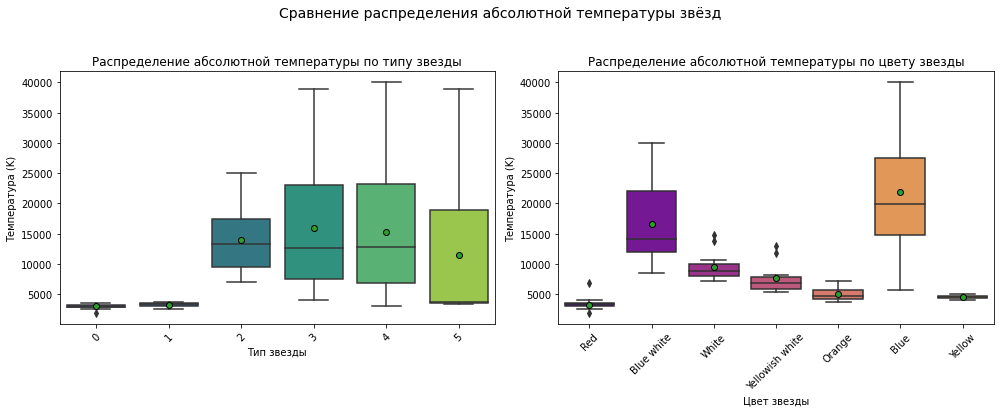

In [18]:
# Создаем фигуру с двумя subplots (рядом)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Первый график: Боксплот по типу звезды
sns.boxplot(
    x='star_type',
    y='temperature_k',
    data=class_6,
    ax=axes[0],                # Указываем ось для первого графика
    palette='viridis',         # Цветовая палитра
    showmeans=True,            # Показывать среднее значение
    meanprops={'marker':'o', 'markeredgecolor':'black'}
)
axes[0].set_title('Распределение абсолютной температуры по типу звезды')
axes[0].set_xlabel('Тип звезды')
axes[0].set_ylabel('Температура (K)')
axes[0].tick_params(axis='x', rotation=45)

# Второй график: Боксплот по цвету звезды
sns.boxplot(
    x='star_color',
    y='temperature_k',
    data=class_6,
    ax=axes[1],                # Указываем ось для второго графика
    palette='plasma',          # Другая цветовая палитра
    showmeans=True,
    meanprops={'marker':'o', 'markeredgecolor':'black'}
)
axes[1].set_title('Распределение абсолютной температуры по цвету звезды')
axes[1].set_xlabel('Цвет звезды')
axes[1].set_ylabel('Температура (K)')
axes[1].tick_params(axis='x', rotation=45)

# Улучшаем оформление
plt.suptitle('Сравнение распределения абсолютной температуры звёзд', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Показываем график
plt.show()

In [19]:
class_6[class_6["star_type"] == 2]["temperature_k"].median()

13380.0

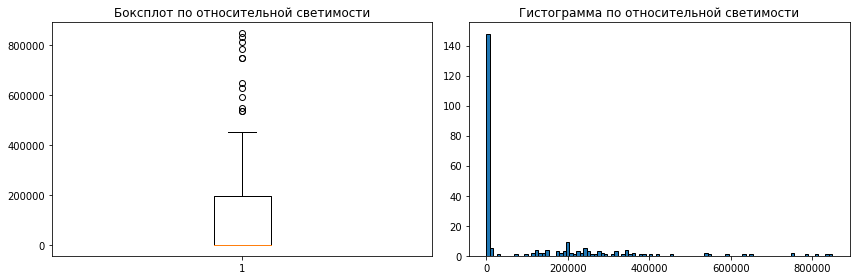

count       240.000000
mean     107188.361635
std      179432.244940
min           0.000080
25%           0.000865
50%           0.070500
75%      198050.000000
max      849420.000000
Name: luminosity_l_lo, dtype: float64

In [20]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(class_6['luminosity_l_lo'])
axes[0].set_title('Боксплот по относительной светимости')

# Второй график — гистограмма
axes[1].hist(class_6['luminosity_l_lo'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по относительной светимости')


# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
class_6['luminosity_l_lo'].describe()

Видим, что распределение с очень сильным скосом вправо. Медиана значительно ниже среднего, которое вверх тянут редкие очень сильные выбросы. Первые два квартиля сосредоточены до светимости 0.7 единиц.

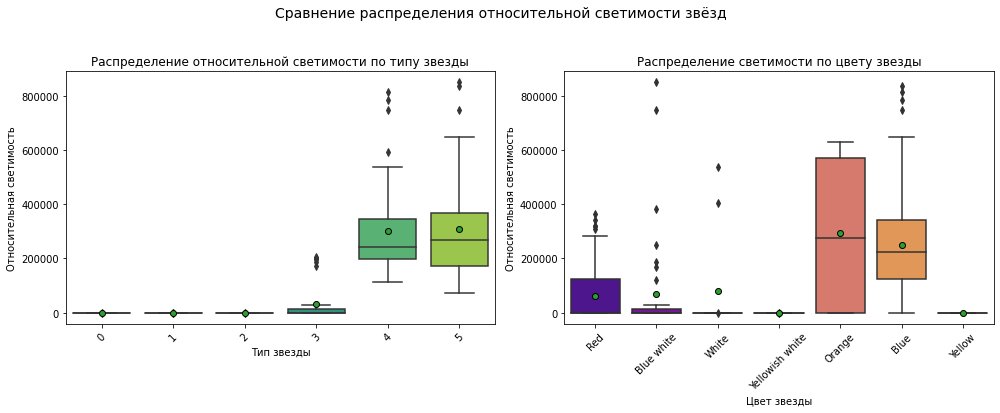

In [21]:
# Создаем фигуру с двумя subplots (рядом)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Первый график: Боксплот по типу звезды
sns.boxplot(
    x='star_type',
    y='luminosity_l_lo',
    data=class_6,
    ax=axes[0],                # Указываем ось для первого графика
    palette='viridis',         # Цветовая палитра
    showmeans=True,            # Показывать среднее значение
    meanprops={'marker':'o', 'markeredgecolor':'black'}
)
axes[0].set_title('Распределение относительной светимости по типу звезды')
axes[0].set_xlabel('Тип звезды')
axes[0].set_ylabel('Относительная светимость')
axes[0].tick_params(axis='x', rotation=45)

# Второй график: Боксплот по цвету звезды
sns.boxplot(
    x='star_color',
    y='luminosity_l_lo',
    data=class_6,
    ax=axes[1],                # Указываем ось для второго графика
    palette='plasma',          # Другая цветовая палитра
    showmeans=True,
    meanprops={'marker':'o', 'markeredgecolor':'black'}
)
axes[1].set_title('Распределение светимости по цвету звезды')
axes[1].set_xlabel('Цвет звезды')
axes[1].set_ylabel('Относительная светимость')
axes[1].tick_params(axis='x', rotation=45)

# Улучшаем оформление
plt.suptitle('Сравнение распределения относительной светимости звёзд', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Показываем график
plt.show()

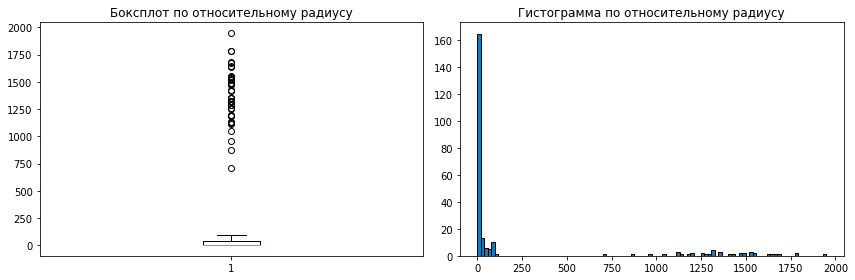

count     240.000000
mean      237.157781
std       517.155763
min         0.008400
25%         0.102750
50%         0.762500
75%        42.750000
max      1948.500000
Name: radius_r_ro, dtype: float64

In [22]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(class_6['radius_r_ro'])
axes[0].set_title('Боксплот по относительному радиусу')

# Второй график — гистограмма
axes[1].hist(class_6['radius_r_ro'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по относительному радиусу')


# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
class_6['radius_r_ro'].describe()

Здесь видим те же черты распределения, что и на первых графиках, только еще более выраженные

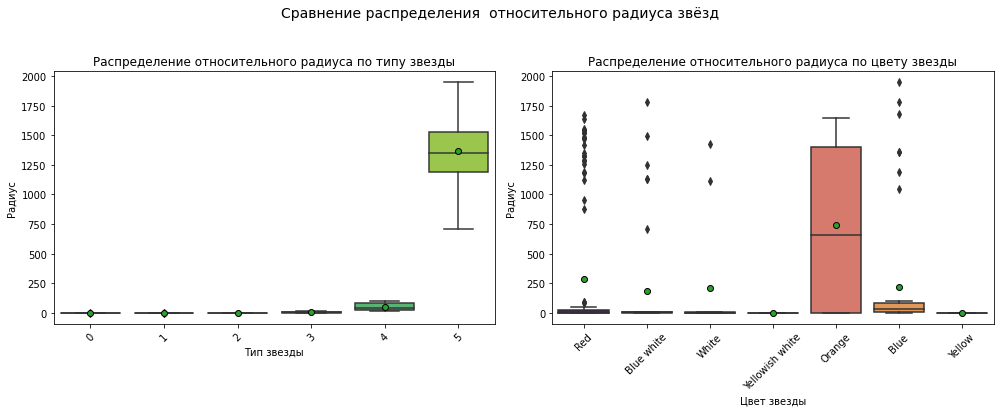

In [23]:
# Создаем фигуру с двумя subplots (рядом)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Первый график: Боксплот по радиусу
sns.boxplot(
    x='star_type',
    y='radius_r_ro',
    data=class_6,
    ax=axes[0],                # Указываем ось для первого графика
    palette='viridis',         # Цветовая палитра
    showmeans=True,            # Показывать среднее значение
    meanprops={'marker':'o', 'markeredgecolor':'black'}
)
axes[0].set_title('Распределение относительного радиуса по типу звезды')
axes[0].set_xlabel('Тип звезды')
axes[0].set_ylabel('Радиус')
axes[0].tick_params(axis='x', rotation=45)

# Второй график: Боксплот по радиусу
sns.boxplot(
    x='star_color',
    y='radius_r_ro',
    data=class_6,
    ax=axes[1],                # Указываем ось для второго графика
    palette='plasma',          # Другая цветовая палитра
    showmeans=True,
    meanprops={'marker':'o', 'markeredgecolor':'black'}
)
axes[1].set_title('Распределение относительного радиуса по цвету звезды')
axes[1].set_xlabel('Цвет звезды')
axes[1].set_ylabel('Радиус')
axes[1].tick_params(axis='x', rotation=45)

# Улучшаем оформление
plt.suptitle('Сравнение распределения  относительного радиуса звёзд', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Показываем график
plt.show()

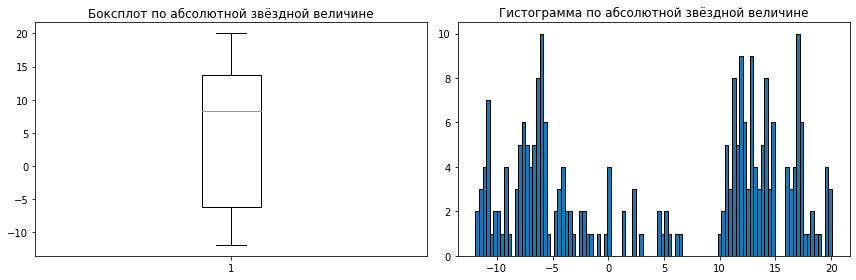

count    240.000000
mean       4.382396
std       10.532512
min      -11.920000
25%       -6.232500
50%        8.313000
75%       13.697500
max       20.060000
Name: absolute_magnitude_mv, dtype: float64

In [24]:
# Создаем фигуру с двумя осями (подграфиками) рядом
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Первый график — boxplot
axes[0].boxplot(class_6['absolute_magnitude_mv'])
axes[0].set_title('Боксплот по абсолютной звёздной величине')

# Второй график — гистограмма
axes[1].hist(class_6['absolute_magnitude_mv'], bins=100, edgecolor='black')
axes[1].set_title('Гистограмма по абсолютной звёздной величине')


# Показываем оба графика
plt.tight_layout()
plt.show()

#Также выведем описательную статистику
class_6['absolute_magnitude_mv'].describe()

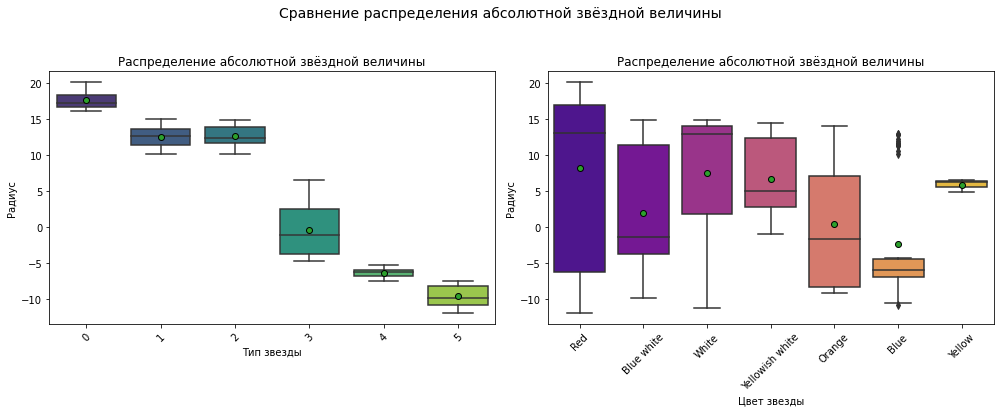

In [25]:
# Создаем фигуру с двумя subplots (рядом)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Первый график: Боксплот по радиусу
sns.boxplot(
    x='star_type',
    y='absolute_magnitude_mv',
    data=class_6,
    ax=axes[0],                # Указываем ось для первого графика
    palette='viridis',         # Цветовая палитра
    showmeans=True,            # Показывать среднее значение
    meanprops={'marker':'o', 'markeredgecolor':'black'}
)
axes[0].set_title('Распределение абсолютной звёздной величины')
axes[0].set_xlabel('Тип звезды')
axes[0].set_ylabel('Радиус')
axes[0].tick_params(axis='x', rotation=45)

# Второй график: Боксплот по радиусу
sns.boxplot(
    x='star_color',
    y='absolute_magnitude_mv',
    data=class_6,
    ax=axes[1],                # Указываем ось для второго графика
    palette='plasma',          # Другая цветовая палитра
    showmeans=True,
    meanprops={'marker':'o', 'markeredgecolor':'black'}
)
axes[1].set_title('Распределение абсолютной звёздной величины')
axes[1].set_xlabel('Цвет звезды')
axes[1].set_ylabel('Радиус')
axes[1].tick_params(axis='x', rotation=45)

# Улучшаем оформление
plt.suptitle('Сравнение распределения абсолютной звёздной величины', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Показываем график
plt.show()

Здесь видим, как наши данные распределены по кластерам: сначала с самой низкой абсолютной звездной величиной идут звезды пятого типа, и дальше с уменьшением типа растет абсолютная звездная величина.

На основе данных графиков можно сделать вывод, что потребуется нормализация числовых признаков (так значения признаков различаются на несколько порядков), а категоризация категориальных признаков.

Учитывая, что у нас признаки не распределены нормально, что иеются как непрерывные, так и дискрертый и категориальный признаки, для проведения корреляционного анализа будем использовать phik-матрицу. 

In [26]:
phik_corr_train = phik_matrix(class_6, interval_cols=['temperature_k', 'luminosity_l_lo', 'radius_r_ro', 'absolute_magnitude_mv'])

In [27]:
phik_corr_train

,temperature_k,luminosity_l_lo,radius_r_ro,absolute_magnitude_mv,star_type,star_color
temperature_k,1.000000,0.562667,0.236637,0.710472,0.603924,0.713357
luminosity_l_lo,0.562667,1.000000,0.574964,0.709456,0.654026,0.429520
radius_r_ro,0.236637,0.574964,1.000000,0.512414,0.635115,0.091675
absolute_magnitude_mv,0.710472,0.709456,0.512414,1.000000,0.915921,0.696759
star_type,0.603924,0.654026,0.635115,0.915921,1.000000,0.665739
star_color,0.713357,0.429520,0.091675,0.696759,0.665739,1.000000


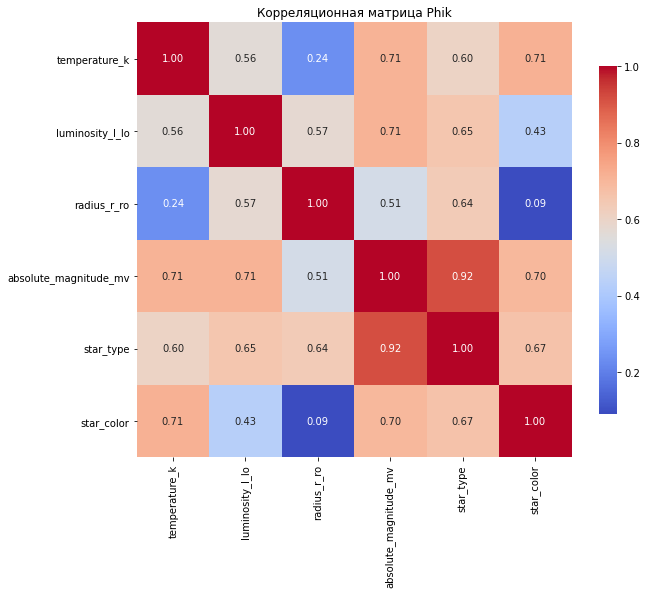

In [28]:
plt.figure(figsize=(10, 8))  
sns.heatmap(phik_corr_train, annot=True, cmap='coolwarm', fmt=".2f", square=True, cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица Phik')
plt.show()


Види, что наиболее сильная связь у таргета temperature_k с непрерывным признаком absolute_magnitude_mv и категориальным признаком star_color.

## Построение базовой нейронной сети

Разделим данные на числовые и категориальные признаки

In [29]:
# Разделим данные на числовые и категориальные признаки
categorical_cols = ['star_type', 'star_color']
numeric_cols = [ 'luminosity_l_lo', 'radius_r_ro', 'absolute_magnitude_mv']

df_cat = class_6[categorical_cols]
df_num = class_6[numeric_cols]

# Определяем целевую переменную
target_col = 'temperature_k'

# Разделяем данные на признаки   и целевую переменную 
X = class_6.drop(columns=[target_col])  
y = class_6[target_col]   

#Нормализация числовых данных  
scaler = StandardScaler()
scaled_numeric = scaler.fit_transform(df_num)

#Кодирование категориальных данных  
ohe = OneHotEncoder(sparse=False)  
encoded_categorical = ohe.fit_transform(df_cat)


In [30]:
# Разделение с использованием стратификации
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=class_6['star_color']
)

In [31]:
# 1. Обрабатываем обучающую выборку
# Категориальные признаки
df_cat_train = X_train[categorical_cols]
ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')
encoded_categorical_train = ohe.fit_transform(df_cat_train)
df_encoded_cat_train = pd.DataFrame(encoded_categorical_train, columns=ohe.get_feature_names_out (categorical_cols), index=X_train.index)

# Числовые признаки
df_num_train = X_train[numeric_cols]
scaler = StandardScaler()
scaled_numeric_train = scaler.fit_transform(df_num_train)
df_scaled_numeric_train = pd.DataFrame(scaled_numeric_train, columns=numeric_cols, index=X_train.index)

# Объединяем все признаки обучающей выборки
X_train_concat = pd.concat([df_scaled_numeric_train, df_encoded_cat_train], axis=1)

In [32]:
# 2. Обрабатываем тестовую выборку (используем те же параметры, что были на обучении)
# Категориальные признаки
df_cat_test = X_test[categorical_cols]
encoded_categorical_test = ohe.transform(df_cat_test)
df_encoded_cat_test = pd.DataFrame(encoded_categorical_test, columns=ohe.get_feature_names_out(categorical_cols), index=X_test.index)

# Числовые признаки
df_num_test = X_test[numeric_cols]
scaled_numeric_test = scaler.transform(df_num_test)
df_scaled_numeric_test = pd.DataFrame(scaled_numeric_test, columns=numeric_cols, index=X_test.index)

# Объединяем все признаки тестовой выборки
X_test_concat = pd.concat([df_scaled_numeric_test, df_encoded_cat_test], axis=1)

In [33]:
# 3. Обработка целевой переменной (температуры)
target_col = 'temperature_k'

# Масштабируем целевую переменную (только на обучающей выборке)
y_train_original = y_train.values.reshape(-1, 1)
scaler_target = StandardScaler()
y_train_scaled = scaler_target.fit_transform(y_train_original).flatten()

# Применяем те же параметры к тестовой выборке
y_test_scaled = scaler_target.transform(y_test.values.reshape(-1, 1)).flatten()

# 4. Преобразуем в тензоры PyTorch
X_train_tensor = torch.FloatTensor(X_train_concat.values)
y_train_tensor = torch.FloatTensor(y_train_scaled.reshape(-1, 1))
X_test_tensor = torch.FloatTensor(X_test_concat.values)
y_test_tensor = torch.FloatTensor(y_test_scaled.reshape(-1, 1))

# 5. Фиксируем воспроизводимость результатов
torch.manual_seed(42)
np.random.seed(42)
torch.use_deterministic_algorithms(True)
random.seed(0)

In [34]:
# СОздадим класс наследующий nn.Module с четырьмя скрытыми слоями
class TemperaturePredictor(nn.Module):
    def __init__(self, input_size):
        super(TemperaturePredictor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 256),  # Входной слой
            nn.ReLU(),
            
            nn.Linear(256, 128),         # Первый скрытый слой
            nn.ReLU(),
            nn.Linear(128, 96),          # Второй скрытый слой
            nn.ReLU(),
            nn.Linear(96, 64),           # Третий скрытый слой
            nn.ReLU(),
            nn.Linear(64, 32),           # Четвёртый скрытый слой (новый)
            nn.ReLU(),
            nn.Linear(32, 1)              # Выходной слой
    )
    
    
    def forward(self, x):
        return self.model(x)

In [35]:
# Создадим функцию обучения 
#которая принимает модель, загрузчик данных, скорость обучения и количество эпох, а затем 
#проводит обучение с выводом промежуточных результатов каждые 25 эпох, также промежуточные результаты по метрике
#будут выводиться на тестовой выборке из-за небольшого объема наблюдений


def train_model_with_test_as_validation(model, train_loader, test_loader, learning_rate=0.0001, epochs=500, patience=10):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.train()
    
    best_test_rmse = float('inf')
    no_improvement_count = 0
    train_losses = []
    test_rmses = []
    
    for epoch in range(epochs):
        # Обучение на тренировочной выборке
        total_loss = 0
        for batch_x, batch_y in train_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Промежуточный вывод результатов на каждые 25 эпох
        if (epoch+1) % 25 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}')
        
        # Тестирование на тестовой выборке (используем как валидационную)
        model.eval()
        with torch.no_grad():
            predicted_test_scaled = model(X_test_tensor).numpy().flatten()
            true_values_test_scaled = y_test_tensor.numpy().flatten()
            
            # Обратное масштабирование в Кельвины
            predicted_test_kelvin = scaler_target.inverse_transform(predicted_test_scaled.reshape(-1, 1)).flatten()
            true_values_test_kelvin = scaler_target.inverse_transform(true_values_test_scaled.reshape(-1, 1)).flatten()
            
            # Расчет RMSE на тестовой выборке
            test_rmse = math.sqrt(mean_squared_error(true_values_test_kelvin, predicted_test_kelvin))
            test_rmses.append(test_rmse)
        
        # Печать промежуточных результатов
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Test RMSE: {test_rmse:.2f}')
        
        # Ранняя остановка
        if test_rmse < best_test_rmse:
            best_test_rmse = test_rmse
            no_improvement_count = 0
            # Сохраняем лучшую модель
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            no_improvement_count += 1
        
        if no_improvement_count >= patience:
            print(f"Ранняя остановка на эпохе {epoch+1}")
            break
    
    # Восстанавливаем лучшую модель
    model.load_state_dict(best_model_state)
    
    # Возвращаем историю потерь и RMSE
    return model, train_losses, test_rmses

In [36]:
# Теперь создадим функцию  оценки качества модели и визуализации результатов 
# в виде гистограммы (план-факт). Функция будет принимать обученную модель, тестовые данные и отображает сравнение предсказаний модели
#с истинными значениями, а также рассчитывает метрику RMSE.

def evaluate_and_plot(model_name, model, X_test_tensor, y_test_tensor):
    model.eval()
    with torch.no_grad():
        # Получаем предсказания в отмасштабированном виде
        predicted_scaled = model(X_test_tensor).numpy().flatten()
    
    true_values_scaled = y_test_tensor.numpy().flatten()
    
    # Обратное масштабирование в Кельвины
    predicted_kelvin = scaler_target.inverse_transform(predicted_scaled.reshape(-1, 1)).flatten()
    true_values_kelvin = scaler_target.inverse_transform(true_values_scaled.reshape(-1, 1)).flatten()
    
    # Расчет RMSE в Кельвинах
    rmse = math.sqrt(mean_squared_error(true_values_kelvin, predicted_kelvin))
    
    print(f"\n--- {model_name} ---")
    print(f"Метрика RMSE: {rmse:.2f}")
    
    # Гистограмма
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Ширина столбцов и отступ между группами
    bar_width = 0.35
    index = np.arange(len(true_values_kelvin))
    
    # Цвет для "Факта"
    rects1 = ax.bar(index - bar_width/2, true_values_kelvin, bar_width, label='Факт', color='#ADD8E6')
    
    # Цвет для "Прогноза"
    rects2 = ax.bar(index + bar_width/2, predicted_kelvin, bar_width, label='Прогноз', color='#FFA500')
    
    # Настройки осей и меток
    ax.set_xlabel('Номер звезды в таблице данных')
    ax.set_ylabel('Температура звезды (К)')
    ax.set_title(f'{model_name}: Факт vs Прогноз')
    ax.set_xticks(index)
    ax.set_xticklabels(index) # Можно заменить на реальные индексы звезд
    ax.legend(loc="lower right")
    
    # Горизонтальная сетка
    ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=.25)
    
    # Показываем график
    plt.show()
    
    return rmse


Epoch [1/500], Train Loss: 1.0086, Test RMSE: 7763.39
Epoch [2/500], Train Loss: 1.0037, Test RMSE: 7734.94
Epoch [3/500], Train Loss: 0.9990, Test RMSE: 7709.89
Epoch [4/500], Train Loss: 0.9944, Test RMSE: 7686.57
Epoch [5/500], Train Loss: 0.9895, Test RMSE: 7663.13
Epoch [6/500], Train Loss: 0.9836, Test RMSE: 7637.37
Epoch [7/500], Train Loss: 0.9772, Test RMSE: 7612.37
Epoch [8/500], Train Loss: 0.9701, Test RMSE: 7587.70
Epoch [9/500], Train Loss: 0.9618, Test RMSE: 7553.90
Epoch [10/500], Train Loss: 0.9530, Test RMSE: 7521.36
Epoch [11/500], Train Loss: 0.9422, Test RMSE: 7475.64
Epoch [12/500], Train Loss: 0.9314, Test RMSE: 7431.24
Epoch [13/500], Train Loss: 0.9169, Test RMSE: 7368.71
Epoch [14/500], Train Loss: 0.9013, Test RMSE: 7297.22
Epoch [15/500], Train Loss: 0.8806, Test RMSE: 7193.18
Epoch [16/500], Train Loss: 0.8541, Test RMSE: 7063.91
Epoch [17/500], Train Loss: 0.8218, Test RMSE: 6908.76
Epoch [18/500], Train Loss: 0.7846, Test RMSE: 6726.04
Epoch [19/500], Tra

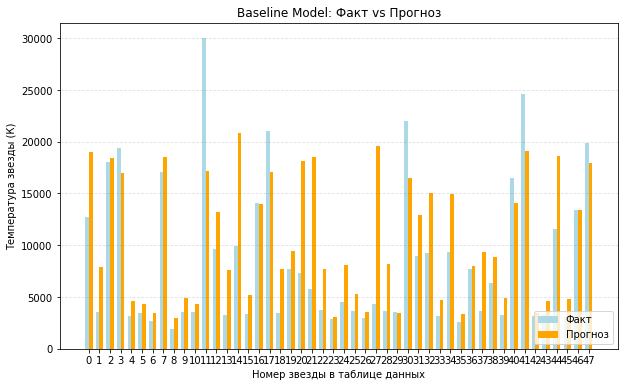

In [37]:
# Создаём модель
input_dim = X_train_concat.shape[1] 
baseline_model = TemperaturePredictor(input_dim)

# Создаём DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Обучение с использованием тестовой выборки как валидационной
trained_model, train_losses, test_rmses = train_model_with_test_as_validation(
    baseline_model, train_loader, test_loader, learning_rate=0.0001, epochs=500, patience=10
)

# Оценка и визуализация на тестовой выборке
baseline_rmse = evaluate_and_plot(
    "Baseline Model",
    trained_model,
    X_test_tensor,
    y_test_tensor
)

Видим на графике, что модель в большинстве случае завышает прогноз относительно факта, при этом на самых высоких фактических температурах модель напротив сильно недооценила значения (проноз заметно ниже), тем сильнее ошибается.

Значение нашей метрики RMSE составило 5547.93

## Улучшение нейронной сети

В первоначально заданную архитектуру добавим Dropout на входном слое, также зададим перечень гиперпараметров для перебора с помощью GridSearch

In [38]:
def build_improved_model(input_size, dropout_rate =0.0):
    """Архитектура остается как в Baseline"""
    return nn.Sequential(
        nn.Linear(input_size, 256),  # Входной слой
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        nn.Linear(256, 128),         # Первый скрытый слой
        nn.ReLU(),
        nn.Linear(128, 96),          # Второй скрытый слой
        nn.ReLU(),
        nn.Linear(96, 64),           # Третий скрытый слой
        nn.ReLU(),
        nn.Linear(64, 32),           # Четвёртый скрытый слой 
        nn.ReLU(),
        nn.Linear(32, 1)              # Выходной слой
    )

param_grid = {
    'dropout': [0.18, 0.19, 0.195, 0.2, 0.21],   
    'batch_size': [64, 72, 80, 88, 96],          
    'learning_rate': [0.00005, 0.0001, 0.0002, 0.0003, 0.0005]   
}
best_rmse = float('inf')
best_params = None
best_model_state = None



In [39]:
for dropout in param_grid['dropout']:
    for batch_size in param_grid['batch_size']:
        for learning_rate in param_grid['learning_rate']:  # Новый внутренний цикл
            print(f"\nТест: dropout={dropout}, batch_size={batch_size}, learning_rate={learning_rate}")
            
            # Создаем и настраиваем модель для текущего цикла
            improved_model = build_improved_model(input_dim, dropout_rate=dropout)
            
            # Готовим DataLoader
            dataset = TensorDataset(X_train_tensor, y_train_tensor)
            loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
            
            # Обучение модели
            train_model_with_test_as_validation(improved_model, loader, learning_rate, epochs=150)
            
            # Оценка на тесте
            improved_model.eval()
            with torch.no_grad():
                predicted = improved_model(X_test_tensor).numpy().flatten()
            
            true_values = y_test_tensor.numpy().flatten()
            rmse = math.sqrt(mean_squared_error(true_values, predicted))
            
            print(f"RMSE для dropout={dropout}, batch={batch_size}, lr={learning_rate}: {rmse:.2f}")
            
            if rmse < best_rmse:
                best_rmse = rmse
                best_params = {'dropout': dropout, 'batch_size': batch_size, 'learning_rate': learning_rate}
                best_model_state = improved_model.state_dict()


Тест: dropout=0.18, batch_size=64, learning_rate=5e-05
Epoch [1/150], Train Loss: 1.0200, Test RMSE: 8028.68
Epoch [2/150], Train Loss: 1.0158, Test RMSE: 8006.88
Epoch [3/150], Train Loss: 1.0131, Test RMSE: 7986.92
Epoch [4/150], Train Loss: 1.0102, Test RMSE: 7968.81
Epoch [5/150], Train Loss: 1.0073, Test RMSE: 7951.46
Epoch [6/150], Train Loss: 1.0042, Test RMSE: 7934.63
Epoch [7/150], Train Loss: 1.0010, Test RMSE: 7917.45
Epoch [8/150], Train Loss: 0.9976, Test RMSE: 7898.44
Epoch [9/150], Train Loss: 0.9940, Test RMSE: 7878.18
Epoch [10/150], Train Loss: 0.9904, Test RMSE: 7858.86
Epoch [11/150], Train Loss: 0.9865, Test RMSE: 7839.89
Epoch [12/150], Train Loss: 0.9824, Test RMSE: 7819.24
Epoch [13/150], Train Loss: 0.9781, Test RMSE: 7799.08
Epoch [14/150], Train Loss: 0.9734, Test RMSE: 7779.13
Epoch [15/150], Train Loss: 0.9683, Test RMSE: 7754.72
Epoch [16/150], Train Loss: 0.9632, Test RMSE: 7730.97
Epoch [17/150], Train Loss: 0.9572, Test RMSE: 7703.93
Epoch [18/150], Tr


--- ЛУЧШИЙ РЕЗУЛЬТАТ ПОИСКА ---
Best RMSE: 0.43
Best Params: {'dropout': 0.19, 'batch_size': 88, 'learning_rate': 0.0002}

--- Best Model (Grid Search) ---
Метрика RMSE: 4273.03


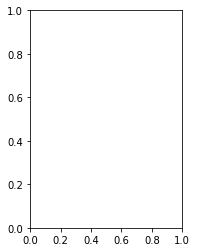

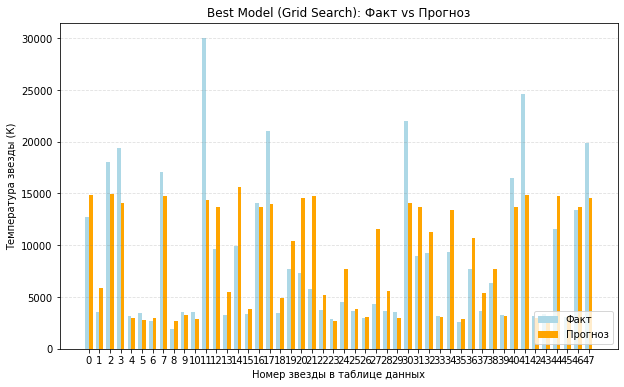

<Figure size 432x288 with 0 Axes>

In [40]:
print(f"\n--- ЛУЧШИЙ РЕЗУЛЬТАТ ПОИСКА ---")
print(f"Best RMSE: {best_rmse:.2f}")
print(f"Best Params: {best_params}")

# Визуализация результата лучшей модели из поиска
final_best_model = build_improved_model(input_dim, dropout_rate=best_params['dropout'])
 
final_best_model.load_state_dict(best_model_state)

plt.subplot(1, 2, 2) # Выводим график рядом с базовым для сравнения
evaluate_and_plot("Best Model (Grid Search)", final_best_model, X_test_tensor, y_test_tensor)
plt.tight_layout()
plt.show()

Видим, что на данном графике те же особенности, что и на базовой модели: наибольшая точность модели при прогнозе температуры до 4000, очень сильное занижение прогноза при аномально высоких фактических значениях температур, в среднем чем выше температура, тем выше ощибка.

## Выводы

Было создано решение с перебором трех параметров нейросети 'dropout', 'batch_size', 'learning_rate'. Архитектура нейросети была сохранена как в базовой модели. Значение удалось RMSE удалось довести до 4273.
Лучшие параметры: 'dropout': 0.19, 'batch_size': 88, 'learning_rate': 0.0002. 